# Forecasting a Time Series

## Load and clean the data - Ridership data of 2001 by Chicago's Transit Authority

In [1]:
import pandas as pd
from pathlib import Path

path = Path('/kaggle/input/datasets/twishhasoni/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv')
df = pd.read_csv(path, parse_dates=['service_date'])
df.columns = ['date', 'day_type', 'bus', "rail", "total"]
df = df.sort_values('date').set_index('date')
df = df.drop('total', axis=1)
df = df.drop_duplicates()

In [2]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


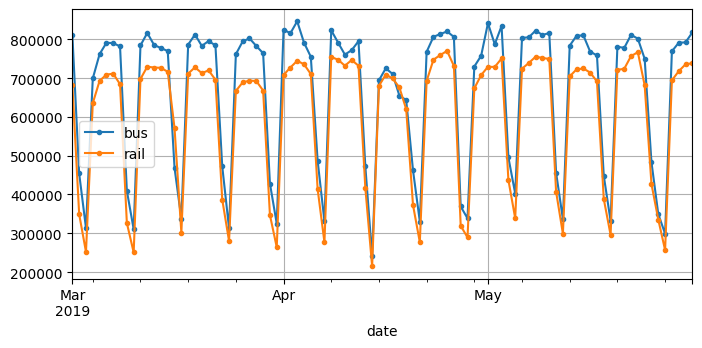

In [3]:
import matplotlib.pyplot as plt
df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

#### using differencing technique to make the data statiionary - reduce the trend
- Here for weekly seasonality

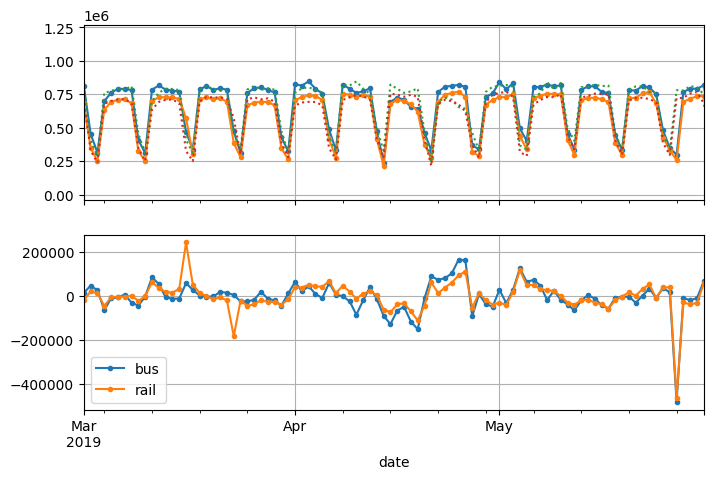

In [4]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".") # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":") # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".") # 7-day difference time series
plt.show()

In [5]:
list(df.loc['2019-05-25':'2019-05-27']['day_type'])

['A', 'U', 'U']

In [6]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [7]:
targets = df[['bus', 'rail']]['2019-03':'2019-05']
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

- Checking yearly seasonality

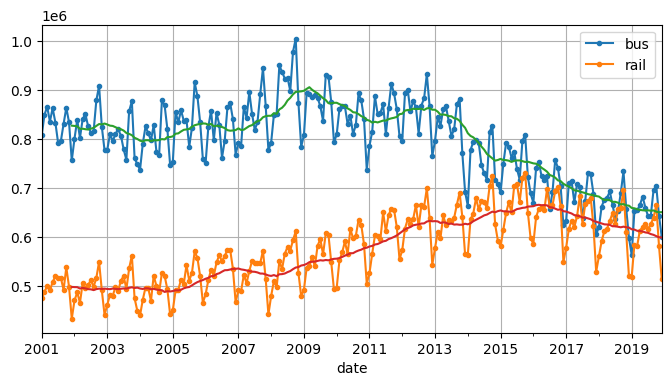

In [8]:
period = slice("2001", "2019")
try:
    df_monthly = df.select_dtypes(include="number").resample('ME').mean()  # compute the mean for each month
    rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
except ValueError as ex:
    try:
        df_monthly = df.select_dtypes(include="number").resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
    except ValueError as ex:
        df_monthly = df.resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

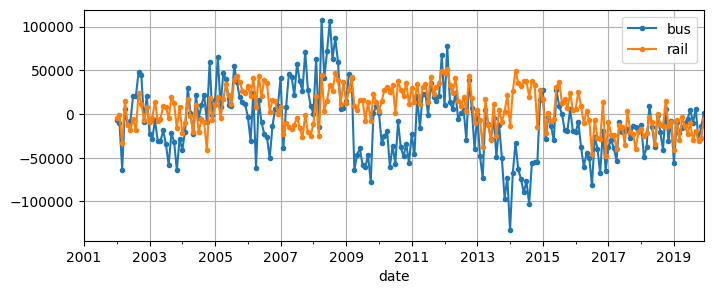

In [9]:
df_monthly.diff(12)[period].plot(grid=True, marker='.', figsize=(8, 3))
plt.show()

## Use ARMA family of model (ARMA, ARIMA, SARIMA)

In [10]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = '2019-01-01', '2019-05-31'
rail_series = df.loc[origin:today]['rail'].asfreq('D')
model = ARIMA(rail_series,
             order=(1,0,0),
             seasonal_order=(0,1,1,7))
model = model.fit()
y_pred = model.forecast()
y_pred

2019-06-01    427758.626288
Freq: D, dtype: float64

In [11]:
import warnings
warnings.filterwarnings("ignore")   

origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today], # train on data up to "today"
        order=(1, 0, 0),
        seasonal_order=(0, 1, 1, 7))
    model = model.fit() # note that we retrain the model every day!
    y_pred = model.forecast()[0]
    y_preds.append(y_pred)
    
y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()

In [12]:
mae

np.float64(32040.72009292839)

## Preparing the data for ml models
- Trying to understand how to use tf.keras.utils.timeseries_dataset_from_array() here

In [13]:
import tensorflow as tf

my_series = [0,1,2,3,4,5]
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
    my_series,
    targets=my_series[3:],
    sequence_length=3,
    batch_size=2
)

I0000 00:00:1785125947.867498      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

In [15]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
for window_tensor in dataset:
    print(f'{window_tensor}')

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [16]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))


In [17]:
dataset = to_windows(tf.data.Dataset.range(6), 4)
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
  array([[0, 1, 2],
         [1, 2, 3]])>,
  <tf.Tensor: shape=(2,), dtype=int64, numpy=array([3, 4])>),
 (<tf.Tensor: shape=(1, 3), dtype=int64, numpy=array([[2, 3, 4]])>,
  <tf.Tensor: shape=(1,), dtype=int64, numpy=array([5])>)]

- Spliting them into train / valid / test 

In [18]:
rail_train = df['rail']['2016-01':'2018-12'] / 1e6
rail_valid = df['rail']['2019-01':'2019-05'] / 1e6
rail_test = df['rail']['2019-06':] / 1e6

In [19]:
seq_length = 56
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets = rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

## Forecasting using Linear Model

In [20]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[seq_length])
])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=50, restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=['mae'])

history = model.fit(train_ds, validation_data=valid_ds, epochs=500,
                   callbacks=[early_stopping_cb])

Epoch 1/500
17/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1300 - mae: 0.4335   

I0000 00:00:1785125952.219085     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0609 - mae: 0.2779 - val_loss: 0.0071 - val_mae: 0.0878
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0085 - mae: 0.0967 - val_loss: 0.0054 - val_mae: 0.0734
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0077 - mae: 0.0892 - val_loss: 0.0064 - val_mae: 0.0796
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0069 - mae: 0.0840 - val_loss: 0.0045 - val_mae: 0.0684
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - mae: 0.0826 - val_loss: 0.0044 - val_mae: 0.0686
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0057 - mae: 0.0758 - val_loss: 0.0044 - val_mae: 0.0636
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0055 - mae: 0.0743 - val_loss: 0.0039 - val_mae: 0.0635
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - mae: 0.0668 - val_loss: 0.0035 - val_mae: 0.0576
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0047 - mae: 0.

In [21]:
valid_loss, valid_mae = model.evaluate(valid_ds)
valid_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0023 - mae: 0.0377


37734.66497659683

## Forecasting using simple RNN

In [22]:
# utility function

def fit_and_evaluate(model, train_set, valid_set, learning_rate=0.02, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=50, restore_best_weights=True)
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(train_set, validation_data=valid_set, epochs=epochs,
                        callbacks=[early_stopping_cb])
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])
fit_and_evaluate(model, train_ds, valid_ds, 0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.2899 - mae: 0.5817 - val_loss: 0.0681 - val_mae: 0.3244
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0506 - mae: 0.2595 - val_loss: 0.0372 - val_mae: 0.2080
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0219 - mae: 0.1556 - val_loss: 0.0167 - val_mae: 0.1468
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0171 - mae: 0.1633 - val_loss: 0.0166 - val_mae: 0.1392
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0166 - mae: 0.1577 - val_loss: 0.0162 - val_mae: 0.1383
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0163 - mae: 0.1577 - val_loss: 0.0158 - val_mae: 0.1379
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0159 - mae: 0.1562 - val_loss: 0.0154 - val_mae: 0.1387
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0156 - mae: 0.1543 - val_loss: 0.0151 - val_mae: 0.1375
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.01

102762.76618242264

In [24]:
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])
fit_and_evaluate(univar_model, train_ds, valid_ds, 0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0302 - mae: 0.1912 - val_loss: 0.0138 - val_mae: 0.1243
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0147 - mae: 0.1429 - val_loss: 0.0140 - val_mae: 0.1534
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0131 - mae: 0.1354 - val_loss: 0.0112 - val_mae: 0.1197
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0088 - mae: 0.1083 - val_loss: 0.0080 - val_mae: 0.1116
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - mae: 0.0946 - val_loss: 0.0075 - val_mae: 0.1067
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - mae: 0.0804 - val_loss: 0.0063 - val_mae: 0.0917
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - mae: 0.0650 - val_loss: 0.0027 - val_mae: 0.0520
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - mae: 0.0580 - val_loss: 0.0025 - val_mae: 0.0459
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

29929.718002676964

## Forecast using a Deep RNN

In [25]:
deep_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])
fit_and_evaluate(deep_model, train_ds, valid_ds, 0.01)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0108 - mae: 0.1086 - val_loss: 0.0032 - val_mae: 0.0618
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0054 - mae: 0.0736 - val_loss: 0.0027 - val_mae: 0.0519
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0045 - mae: 0.0636 - val_loss: 0.0022 - val_mae: 0.0412
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0043 - mae: 0.0615 - val_loss: 0.0028 - val_mae: 0.0532
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0042 - mae: 0.0624 - val_loss: 0.0020 - val_mae: 0.0375
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0037 - mae: 0.0545 - val_loss: 0.0019 - val_mae: 0.0352
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0038 - mae: 0.0574 - val_loss: 0.0028 - val_mae: 0.0501
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0039 - mae: 0.0577 - val_loss: 0.0018 - val_mae: 0.0333
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - lo

29431.4231723547

## Forecasting multivariate Time Series

In [26]:
df_mulvar = df[['bus', 'rail']]
df_mulvar['next_day_type'] = df['day_type'].shift(-1)
df_mulvar = pd.get_dummies(df_mulvar)

In [27]:
mulvar_train = df_mulvar["2016-01":"2018-12"] / 1e6
mulvar_valid = df_mulvar["2019-01":"2019-05"] / 1e6
mulvar_test = df_mulvar["2019-06":] / 1e6

In [28]:
tf.random.set_seed(42)  
train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  # use all 5 columns as input
    targets=mulvar_train["rail"][seq_length:],  # forecast only the rail series
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

In [29]:
mulvar_model = tf.keras.Sequential([
tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
tf.keras.layers.Dense(1)
])
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds, 0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0196 - mae: 0.1411 - val_loss: 0.0034 - val_mae: 0.0604
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - mae: 0.0663 - val_loss: 0.0025 - val_mae: 0.0451
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - mae: 0.0551 - val_loss: 0.0026 - val_mae: 0.0410
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - mae: 0.0528 - val_loss: 0.0023 - val_mae: 0.0395
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - mae: 0.0523 - val_loss: 0.0027 - val_mae: 0.0440
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - mae: 0.0501 - val_loss: 0.0027 - val_mae: 0.0474
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - mae: 0.0515 - val_loss: 0.0021 - val_mae: 0.0355
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mae: 0.0513 - val_loss: 0.0028 - val_mae: 0.0482
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

30858.155339956284

In [31]:
tf.random.set_seed(42)

seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=mulvar_train[["bus", "rail"]][seq_length:],  # 2 targets per day
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid[["bus", "rail"]][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

tf.random.set_seed(42)
multask_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(2)
])

fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0639 - mae: 0.2620 - val_loss: 0.0107 - val_mae: 0.1181
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0074 - mae: 0.0928 - val_loss: 0.0042 - val_mae: 0.0698
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0047 - mae: 0.0689 - val_loss: 0.0031 - val_mae: 0.0580
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - mae: 0.0615 - val_loss: 0.0029 - val_mae: 0.0558
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - mae: 0.0586 - val_loss: 0.0029 - val_mae: 0.0543
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037 - mae: 0.0568 - val_loss: 0.0025 - val_mae: 0.0483
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - mae: 0.0560 - val_loss: 0.0023 - val_mae: 0.0464
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - mae: 0.0550 - val_loss: 0.0024 - val_mae: 0.0465
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

32785.62426567078

In [32]:
Y_preds_valid = multask_model.predict(valid_multask_ds)
for idx, name in enumerate(["bus", "rail"]):
    mae = 1e6 * tf.keras.metrics.MeanAbsoluteError()(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
bus 33414
rail 32156


## Forecasting Several Time Steps AheadForecasting Several Time Steps Ahead

In [33]:
import numpy as np

X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [34]:
tf.random.set_seed(42) 

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32,
    shuffle=True,
    seed=42
).map(split_inputs_and_targets)
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

In [35]:
tf.random.set_seed(42)

ahead_model = tf.keras.Sequential([
tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
tf.keras.layers.Dense(14)
])
fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0952 - mae: 0.3310 - val_loss: 0.0219 - val_mae: 0.1591
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0169 - mae: 0.1455 - val_loss: 0.0132 - val_mae: 0.1303
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0135 - mae: 0.1331 - val_loss: 0.0114 - val_mae: 0.1212
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - mae: 0.1250 - val_loss: 0.0100 - val_mae: 0.1138
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0109 - mae: 0.1183 - val_loss: 0.0089 - val_mae: 0.1056
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098 - mae: 0.1107 - val_loss: 0.0077 - val_mae: 0.0987
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0089 - mae: 0.1042 - val_loss: 0.0067 - val_mae: 0.0919
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0082 - mae: 0.0989 - val_loss: 0.0059 - val_mae: 0.0860
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

30577.40069925785

In [36]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]  # shape [1, 56, 5]
Y_pred = ahead_model.predict(X)
Y_pred.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step


(1, 14)